In [1]:
import pandas as pd
shah_alam = pd.read_csv('D:\Problems\Dataset_Practice\Shah_Alam_Data_Analysis\House_Data.csv', sep = ',')
shah_alam['Name'] = shah_alam['Name'].str.replace('SHAH ALAM, SELANGOR|SHAH ALAM', '', regex=True, case=False).str.strip()

shah_alam['Tenure_Class'] = shah_alam['Tenure_Type'].str.extract(r'(FREEHOLD,?\s*LEASEHOLD|FREEHOLD|LEASEHOLD)', flags=2)[0]
shah_alam['Tenure_Type'] = shah_alam['Tenure_Type'].str.replace(r'FREEHOLD,?\s*LEASEHOLD|FREEHOLD|LEASEHOLD', '', regex=True, case=False).str.strip()
shah_alam['Tenure_Type'] = shah_alam['Tenure_Type'].str.replace(r'^,\s*|,\s*$', '', regex=True).str.strip()
shah_alam['Name'] = shah_alam['Name'].str.replace(',','', regex=True).str.strip()
shah_alam['Filed_Transactions'] = shah_alam['Filed_Transactions'].str.replace(r'Transactions|Transaction', '', regex=True).str.strip().astype('int')
shah_alam['Median_Price'] = shah_alam['Median_Price'].str.replace(',','').str.strip().astype('int')
shah_alam['Median_Price_Psf'] = shah_alam['Median_Price_Psf'].str.replace(',','').str.strip().astype('int')

column_to_move = shah_alam.pop('Tenure_Class')
shah_alam.insert(1, 'Tenure_Class', column_to_move)
shah_alam



,Name,Tenure_Class,Tenure_Type,Median_Price_Psf,Median_Price,Filed_Transactions
0,ELMINA WEST,FREEHOLD,"SEMI-D, TERRACE HOUSE",692,1184888,170
1,ALAM IMPIAN,FREEHOLD,"CLUSTER HOUSE, SEMI-D, TERRACE HOUSE",633,920400,90
2,BUKIT JELUTONG,FREEHOLD,"BUNGALOW, CLUSTER HOUSE, SEMI-D, TERRACE HOUSE",458,1085000,71
3,SEKSYEN 30,"FREEHOLD, LEASEHOLD","BUNGALOW, SEMI-D, TERRACE HOUSE",339,570000,71
4,KOTA KEMUNING,"FREEHOLD, LEASEHOLD","SEMI-D, TERRACE HOUSE",476,900000,56
...,...,...,...,...,...,...
193,TAMAN SRI AMAN (P/L 2809),FREEHOLD,TERRACE HOUSE,371,435000,1
194,TAMAN SRI KEMUNING (P/L 1323),FREEHOLD,TERRACE HOUSE,282,520000,1
195,TAMAN SRI LEMBAYUNG,FREEHOLD,FLAT,211,137000,1
196,TAMAN SRI MUDA SEKSYEN 25,FREEHOLD,FLAT,159,90000,1


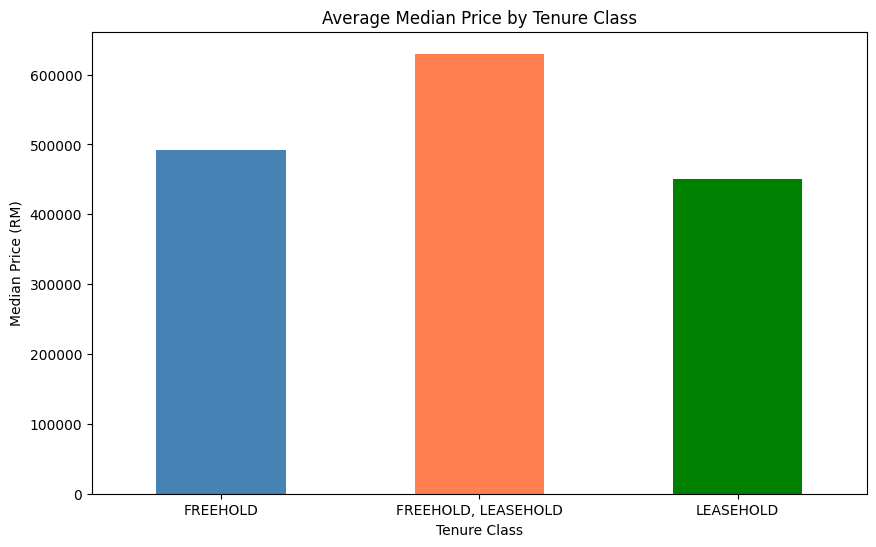

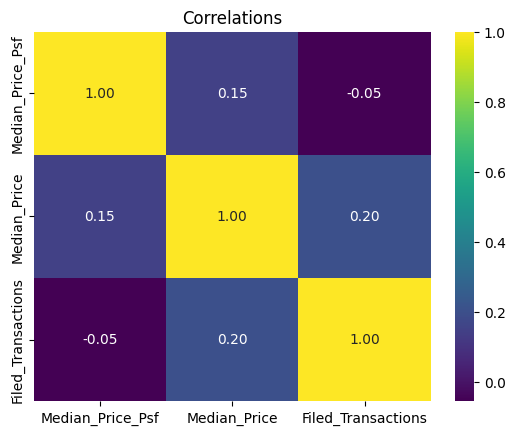

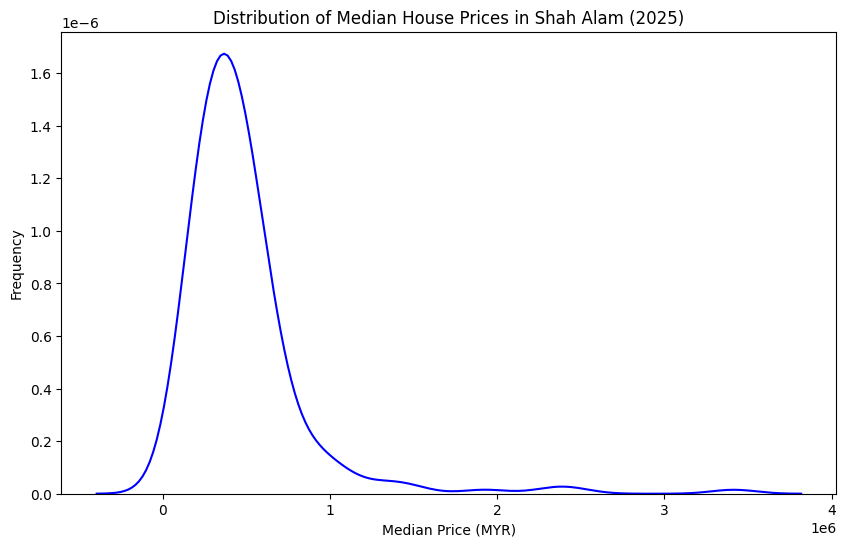

Most common price point (mode): RM 400,000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

average_freehold = shah_alam.groupby('Tenure_Class')[['Median_Price_Psf', 'Median_Price', 'Filed_Transactions']].mean()
value = round(average_freehold, 2)

# Bar Chart
plt.figure(figsize=(10, 6))
value['Median_Price'].plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Average Median Price by Tenure Class')
plt.xlabel('Tenure Class')
plt.ylabel('Median Price (RM)')
plt.xticks(rotation=360)
plt.show()

# HeatMap
subset = shah_alam[['Median_Price_Psf','Median_Price','Filed_Transactions']]
fig = sns.heatmap(subset.corr(), cmap = 'viridis', fmt = '.2f', annot = True)
plt.title('Correlations')

# Distribution with KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(shah_alam['Median_Price'], color='blue')
plt.title('Distribution of Median House Prices in Shah Alam (2025)')
plt.xlabel('Median Price (MYR)')
plt.ylabel('Frequency')
plt.show()

# Print the peak value separately
print(f"Most common price point (mode): RM {shah_alam['Median_Price'].mode()[0]:,}")